## Preamble

In [1]:
import os
import numpy as np
#from scipy import signal
import matplotlib.pyplot as plt

In [157]:
vp=3000
vs=0.
rho=2500

nz=241; nx=241; h=5
nzsnap=289; nxsnap=289; nsnap=51

fpeak=15

dt=0.0004
nt=2500
t=np.arange(0,nt*dt,dt)-0.067

nr=1

In [158]:
!makevel nx=$nx nz=$nz v000=$vp > vp
!makevel nx=$nx nz=$nz v000=$vs > vs
!makevel nx=$nx nz=$nz v000=$rho> rho
!cat vp vs rho > model

In [159]:
def read(filename,n=(nx,nz)):
    return np.fromfile(filename,dtype='float32').reshape(n).T

def read_su(filename,n=(nr,nt)):
    data=read(filename,n=(n[0],int(60+n[1])))
    return data[60:,:]

def read_snap(filename,n=(nsnap,nxsnap,nzsnap),i=17):
    tmp=np.fromfile(filename,dtype='float32').reshape(n).T
#     return tmp[:,:,i]
    return tmp[24:24+nz,24:24+nx,i]

def imshow(data,perc=None,clip=None,clipmin=None,extent=None,cmap='viridis',title=None,grid=True):
    
    if perc==None:
        clipp=[np.amin(data),np.amax(data)]
    else:
        tmp=np.percentile(np.abs(data),q=perc)
        clipp=[-tmp,tmp]
    
    if clip!=None: clipp=clip
    
    if clipmin!=None: clipp[0]=clipmin
    
    plt.imshow(data,vmin=clipp[0],vmax=clipp[1],extent=extent,cmap=cmap,aspect='auto')
    plt.colorbar(location='right')
    plt.grid(visible=grid, axis='both', which='both', color='w', linestyle='--',linewidth=0.5)
    #plt.xlabel(labels[0]); plt.ylabel(labels[1])
    if title!=None: plt.title(title)

def run(app='../../exe/FWI',setup='setup',np=1,nthreads=8,out=None):
    '''
    run(app,setup,np=1,nthreads=8)
    run in a bash env
    ----------------------------
    app      : application/executable to run
    setup    : setup file
    np       : number of MPI processors (default=1)
    nthreads : number of OpenMP threads (default=8)
    
    Caveat: np*nthreads should not exceed total number of CPU cores
    otherwise the running will be very slow
    '''
    
    !echo 'ulimit -s unlimited' > run.sh
    str=f"export OMP_NUM_THREADS={nthreads}"
    !echo $str >> run.sh
    str=f"{app} {setup}"
    !echo $str >> run.sh
    !chmod +x run.sh
    if out==None:
        !./run.sh
    else:
        !./run.sh > {out}

In [169]:
!cat setup_default2

MODEL_SIZE              '241   241   1'
MODEL_SPACING           '5     5     1'
MODEL_ORIGIN            '0     0     0'
FILE_MODEL              'model'
MODEL_ATTRIBUTES        'vp vs rho'

ACQUI_GEOMETRY          spread
FS                      ' 0   100 0'
FR                      '30  1100 0'
DR                      ' 0     0 0'
NR                       1

SCOMP                    vx
RCOMP                   'vz vx p'

NT           2500
DT           0.0004
WAVELET_TYPE ricker
FPEAK        15

#SNAPSHOT     'vz vx szz sxx szx'
IF_SNAPSHOT   T

IF_USE_CHECKPOINT   F


#why the vz comp of dsyn is weird?


## Test vforce
Robertsson, Fig 1,2

In [65]:
!compile_all.sh

(cd Modules/System; make clean)
make[1]: Entering directory '/home/wzhou/Codes/GitHub/SeisJIMU/Modules/System'
rm m_either.o m_string.o m_mpienv.o m_message.o m_arrayop.o m_setup.o m_sysio.o m_checkpoint.o m_suformat.o m_System.o

rm ../../mod/m_either.mod ../../mod/m_string.mod ../../mod/m_mpienv.mod ../../mod/m_message.mod ../../mod/m_arrayop.mod ../../mod/m_setup.mod ../../mod/m_sysio.mod ../../mod/m_checkpoint.mod ../../mod/m_suformat.mod ../../mod/m_System.mod ../../mod/m_system.mod
rm: cannot remove '../../mod/m_System.mod': No such file or directory
make[1]: [Makefile:25: clean] Error 1 (ignored)

make[1]: Leaving directory '/home/wzhou/Codes/GitHub/SeisJIMU/Modules/System'
(cd Modules/Etc; make clean)
make[1]: Entering directory '/home/wzhou/Codes/GitHub/SeisJIMU/Modules/Etc'
rm sgtsv.o m_math.o singleton.o

rm ../../mod/m_math.mod ../../mod/singleton.mod

make[1]: Leaving directory '/home/wzhou/Codes/GitHub/SeisJIMU/Modules/Etc'
(cd Modules/Signal; make clean)
make[1]: Enterin


mpif90 -cpp -Dgfortran -D"git_commit='116cb9c'" -D"git_branch='VisAC_ZFL_WZ'" -g -Wall -Wno-tabs -fopenmp -fcheck=all -ffree-line-length-none -fbacktrace -fno-strict-aliasing -J ../../mod/ -c m_setup.f90 -o m_setup.o
m_setup.f90:428:31:

  428 |     function previous_bool(self) result(res)
      |                               1
m_setup.f90:420:31:

  420 |     function previous_file(self) result(res)
      |                               1
m_setup.f90:411:31:

  411 |     function previous_strs(self,o_sep) result(res)
      |                               1
m_setup.f90:403:30:

  403 |     function previous_str(self) result(res)
      |                              1
m_setup.f90:394:32:

  394 |     function previous_reals(self,o_sep) result(res)
      |                                1
m_setup.f90:386:31:

  386 |     function previous_real(self) result(res)
      |                               1
m_setup.f90:377:31:

  377 |     function previous_ints(self,o_sep) result(res)
      


mpif90 -cpp -Dgfortran -D"git_commit='116cb9c'" -D"git_branch='VisAC_ZFL_WZ'" -g -Wall -Wno-tabs -fopenmp -fcheck=all -ffree-line-length-none -fbacktrace -fno-strict-aliasing -J ../../mod/ -c m_checkpoint.f90 -o m_checkpoint.o
m_checkpoint.f90:172:24:

  172 |         integer filesize
      |                        1

mpif90 -cpp -Dgfortran -D"git_commit='116cb9c'" -D"git_branch='VisAC_ZFL_WZ'" -g -Wall -Wno-tabs -fopenmp -fcheck=all -ffree-line-length-none -fbacktrace -fno-strict-aliasing -J ../../mod/ -c m_suformat.f90 -o m_suformat.o
m_suformat.f90:433:30:

  433 |         if(hdr1%ns<0) hdr1%ns=hdr1%ns+32768*2  !ns keyword is unsigned short in C
      |                              1
m_suformat.f90:434:30:

  434 |         if(hdr1%dt<0) hdr1%dt=hdr1%dt+32768*2  !dt keyword is unsigned short in C
      |                              1
m_suformat.f90:406:24:

  406 |         self%hdrs(:)%ns=self%ns
      |                        1
m_suformat.f90:407:42:

  407 |         if(present(o_

m_Hilbert.f90:152:20:

  152 |         integer :: i, mid
      |                    1
m_Hilbert.f90:152:25:

  152 |         integer :: i, mid
      |                         1
m_Hilbert.f90:21:67:

   21 |         dfft = fft(dcmplx(din))  !may require "ulimit -s unlimited"
      |                                                                   ^
m_Hilbert.f90:17:57:

   17 |         complex(fftkind),dimension(:),allocatable :: dfft
      |                                                         ^
note: ‘dfft’ declared here
m_Hilbert.f90:21:67:

   21 |         dfft = fft(dcmplx(din))  !may require "ulimit -s unlimited"
      |                                                                   ^
m_Hilbert.f90:17:57:

   17 |         complex(fftkind),dimension(:),allocatable :: dfft
      |                                                         ^
note: ‘dfft’ declared here
m_Hilbert.f90:21:67:

   21 |         dfft = fft(dcmplx(din))  !may require "ulimit -s unlimited"
      |        


mpif90 -cpp -Dgfortran -D"git_commit='116cb9c'" -D"git_branch='VisAC_ZFL_WZ'" -g -Wall -Wno-tabs -fopenmp -fcheck=all -ffree-line-length-none -fbacktrace -fno-strict-aliasing -J ../../mod/ -c m_computebox.f90 -o m_computebox.o
m_computebox.f90:253:19:

  253 |     subroutine cb2m(big,small)
      |                   ^

mpif90 -cpp -Dgfortran -D"git_commit='116cb9c'" -D"git_branch='VisAC_ZFL_WZ'" -g -Wall -Wno-tabs -fopenmp -fcheck=all -ffree-line-length-none -fbacktrace -fno-strict-aliasing -J ../../mod/ -c m_field.f90 -o m_field.o
m_field.f90:461:63:

  461 |     subroutine boundary_transport(self,action,it,o_vz,o_vx,o_vy,o_p)
      |                                                               1
m_field.f90:381:29:

  381 |     subroutine write_ext(self,it,name,data,n)
      |                             1
m_field.f90:275:26:

  275 |     subroutine reinit(self)
      |                          1

mpif90 -cpp -Dgfortran -D"git_commit='116cb9c'" -D"git_branch='VisAC_ZFL_WZ'" -g -Wal

...


mpif90 -cpp -Dgfortran -D"git_commit='116cb9c'" -D"git_branch='VisAC_ZFL_WZ'" -g -Wall -Wno-tabs -fopenmp -fcheck=all -ffree-line-length-none -fbacktrace -fno-strict-aliasing -J ../../mod/ -c m_sysio.f90 -o m_sysio.o
m_sysio.f90:86:45:

   86 |     subroutine sysio_read(file,array,n,o_mode,o_iproc)
      |                                             1
m_sysio.f90:53:28:

   53 |         integer :: file_size
      |                            1
m_sysio.f90:54:50:

   54 |         real,dimension(:),allocatable :: tmp_array
      |                                                  1

mpif90 -cpp -Dgfortran -D"git_commit='116cb9c'" -D"git_branch='VisAC_ZFL_WZ'" -g -Wall -Wno-tabs -fopenmp -fcheck=all -ffree-line-length-none -fbacktrace -fno-strict-aliasing -J ../../mod/ -c m_checkpoint.f90 -o m_checkpoint.o
m_checkpoint.f90:172:24:

  172 |         integer filesize
      |                        1

mpif90 -cpp -Dgfortran -D"git_commit='116cb9c'" -D"git_branch='VisAC_ZFL_WZ'" -g -Wall -Wno-


mpif90 -cpp -Dgfortran -D"git_commit='116cb9c'" -D"git_branch='VisAC_ZFL_WZ'" -g -Wall -Wno-tabs -fopenmp -fcheck=all -ffree-line-length-none -fbacktrace -fno-strict-aliasing -J ../../mod/ -c m_Hilbert.f90 -o m_Hilbert.o
m_Hilbert.f90:141:13:

  141 |         dout=2.*aimag(fft(dfft,dim=[axis],inv=.true.))
      |             1
m_Hilbert.f90:155:15:

  155 |         dfft = fft(dcmplx(din), dim=[1])
      |               1
m_Hilbert.f90:169:15:

  169 |         dout = 2.0 * aimag(fft(dcmplx(dfft), dim=[1], inv=.true.))
      |               1
m_Hilbert.f90:80:13:

   80 |         dout=2.*aimag(fft(dfft,dim=[axis],inv=.true.))
      |             1
m_Hilbert.f90:35:13:

   35 |         dout=2.*aimag(fft(dfft,inv=.true.))
      |             1
m_Hilbert.f90:152:20:

  152 |         integer :: i, mid
      |                    1
m_Hilbert.f90:152:25:

  152 |         integer :: i, mid
      |                         1
m_Hilbert.f90:21:67:

   21 |         dfft = fft(dcmplx(din))  !may requ

m_model.f90:108:45:

  108 |         character(:),allocatable :: file, str
      |                                             1
m_model.f90:48:29:

   48 |     subroutine estim_RAM(self)
      |                             1

mpif90 -cpp -Dgfortran -D"git_commit='116cb9c'" -D"git_branch='VisAC_ZFL_WZ'" -g -Wall -Wno-tabs -fopenmp -fcheck=all -ffree-line-length-none -fbacktrace -fno-strict-aliasing -J ../../mod/ -c m_shotlist_batching.f90 -o m_shotlist_batching.o

mpif90 -cpp -Dgfortran -D"git_commit='116cb9c'" -D"git_branch='VisAC_ZFL_WZ'" -g -Wall -Wno-tabs -fopenmp -fcheck=all -ffree-line-length-none -fbacktrace -fno-strict-aliasing -J ../../mod/ -c m_shot.f90 -o m_shot.o
m_shot.f90:1046:34:

 1046 |             sudata%hdrs(:)%scalel=int(scalel)
      |                                  1
m_shot.f90:1047:34:

 1047 |             sudata%hdrs(:)%scalco=int(scalco)
      |                                  1
m_shot.f90:1052:39:

 1052 |                 sudata%hdrs(i)%sdepth= (self%src%z+

m_field.f90:461:63:

  461 |     subroutine boundary_transport(self,action,it,o_vz,o_vx,o_vy,o_p)
      |                                                               1
m_field.f90:381:29:

  381 |     subroutine write_ext(self,it,name,data,n)
      |                             1
m_field.f90:275:26:

  275 |     subroutine reinit(self)
      |                          1

mpif90 -cpp -Dgfortran -D"git_commit='116cb9c'" -D"git_branch='VisAC_ZFL_WZ'" -g -Wall -Wno-tabs -fopenmp -fcheck=all -ffree-line-length-none -fbacktrace -fno-strict-aliasing -J ../../mod/ -c m_cpml.f90 -o m_cpml.o

mpif90 -cpp -Dgfortran -D"git_commit='116cb9c'" -D"git_branch='VisAC_ZFL_WZ'" -g -Wall -Wno-tabs -fopenmp -fcheck=all -ffree-line-length-none -fbacktrace -fno-strict-aliasing -J ../../mod/ -c m_freesurface.f90 -o m_freesurface.o

mpif90 -cpp -Dgfortran -D"git_commit='116cb9c'" -D"git_branch='VisAC_ZFL_WZ'" -g -Wall -Wno-tabs -fopenmp -fcheck=all -ffree-line-length-none -fbacktrace -fno-strict-aliasing -J 


mpif90 -g -Wall -Wno-tabs -fopenmp -fcheck=all -ffree-line-length-none -fbacktrace -fno-strict-aliasing -J ../mod/ ../Modules/System/*.o ../Modules/Etc/*.o ../Modules/Signal/*.o ../Modules/Modeling/m_model.o ../Modules/Modeling/m_shotlist_batching.o ../Modules/Modeling/m_shot.o ../Modules/Modeling/m_computebox.o ../Modules/Modeling/m_field.o ../Modules/Modeling/m_cpml.o ../Modules/Modeling/m_freesurface.o ../Modules/Modeling/m_correlate.o ../Modules/Modeling/m_propagator_PSV2nd_FDSG_O4.o ../Modules/Modeling/m_Modeling.o main.o -o ../exe/fwd_PSV2nd_FDSG_O4_
(cd ../exe; ln -sf fwd_PSV2nd_FDSG_O4_ FWD )
make[1]: Leaving directory '/home/wzhou/Codes/GitHub/SeisJIMU/FWD'

/home/wzhou/Codes/GitHub/SeisJIMU/Demo/01_ForwardModeling_FreeSurface


### No FS

In [170]:
# AC modeling
!cp setup_default2 setup
!echo "FS          '100   100 0'" >>setup
!echo "FR          '600   600 0'" >>setup
!echo "IS_FREESURFACE   F" >>setup
!echo "SCOMP            vz" >> setup
!echo "RCOMP           'vz vx'" >> setup
!echo "DIR_OUT       res_AC" >> setup
run(app='../../exe/fwd_AC_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           8
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/01_ForwardModeling_FreeSurface
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 wzhou wzhou 747248 Nov  9 15:56 ../../exe/fwd_AC_FDSG_O4_
 Git Commit: 2496904
 Git Branch: VisAC_ZFL_WZ
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 11/09/2025
System time: 15:58:28
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : res_AC
 Output directory:res_AC/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D/3D ACoustic propagation
1st-order Velocity-Stress(Pressure) formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   ->

In [177]:
# AC2nd modeling
!cp setup_default2 setup
!echo "FS          '100   100 0'" >>setup
!echo "FR          '600   600 0'" >>setup
!echo "IS_FREESURFACE   F" >>setup
!echo "SCOMP            az" >> setup
!echo "RCOMP           'az ax'" >> setup
!echo "DIR_OUT       res_AC2nd" >> setup
run(app='../../exe/fwd_AC2nd_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           8
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/01_ForwardModeling_FreeSurface
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 wzhou wzhou 738592 Nov  9 16:15 ../../exe/fwd_AC2nd_FDSG_O4_
 Git Commit: 2496904
 Git Branch: VisAC_ZFL_WZ
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 11/09/2025
System time: 16:17:26
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : res_AC2nd
 Output directory:res_AC2nd/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D/3D ACoustic propagation
2nd-order Pressure formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   -> dt ≤ 0.

In [171]:
# PSV modeling
!cp setup_default2 setup
!echo "FS          '100   100 0'" >>setup
!echo "FR          '600   600 0'" >>setup
!echo "IS_FREESURFACE   F" >>setup
!echo "SCOMP            vz" >> setup
!echo "RCOMP           'vz vx'" >> setup
!echo "DIR_OUT       res_PSV" >> setup
run(app='../../exe/fwd_PSV_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           8
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/01_ForwardModeling_FreeSurface
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 wzhou wzhou 751736 Nov  9 15:02 ../../exe/fwd_PSV_FDSG_O4_
 Git Commit: 2496904
 Git Branch: VisAC_ZFL_WZ
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 11/09/2025
System time: 15:58:34
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : res_PSV
 Output directory:res_PSV/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D P-SV (ELastic) propagation
1st-order Velocity-Stress formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   -> dt 

In [172]:
# PSV2nd modeling
!cp setup_default2 setup
!echo "FS          '100   100 0'" >>setup
!echo "FR          '600   600 0'" >>setup
!echo "IS_FREESURFACE   F" >>setup
!echo "SCOMP            uz" >> setup
!echo "RCOMP           'uz ux'" >> setup
!echo "DIR_OUT       res_PSV2nd" >> setup
run(app='../../exe/fwd_PSV2nd_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           8
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/01_ForwardModeling_FreeSurface
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 wzhou wzhou 759344 Nov  9 14:18 ../../exe/fwd_PSV2nd_FDSG_O4_
 Git Commit: 2496904
 Git Branch: VisAC_ZFL_WZ
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 11/09/2025
System time: 15:58:40
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : res_PSV2nd
 Output directory:res_PSV2nd/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D PSV (ELastic) propagation
2nd-order Displacement formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   -

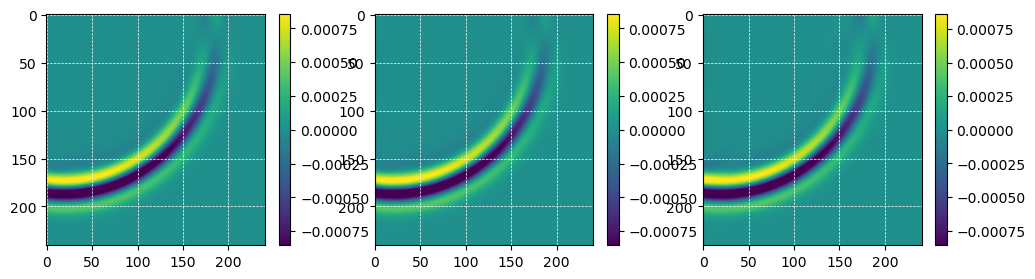

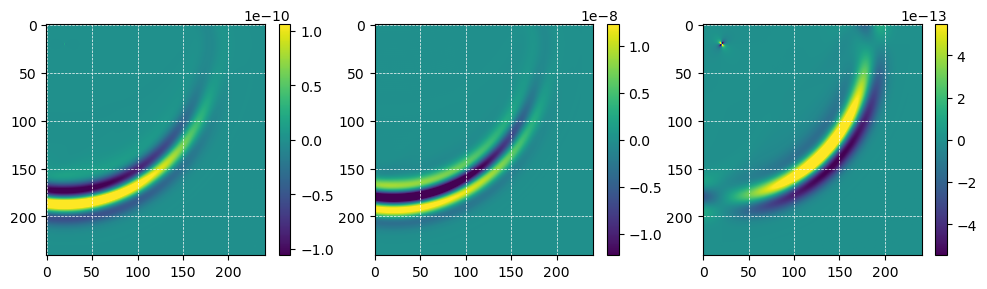

In [178]:
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read_snap('res_AC/snap_fld_reU%p'),perc=98) #pressure
plt.subplot(1,3,2); imshow(read_snap('res_AC2nd/snap_fld_reU%p'),perc=98) #pressure
plt.subplot(1,3,3); imshow((read_snap('res_PSV/snap_fld_reU%sz')+read_snap('res_PSV/snap_fld_reU%sx'))/2,perc=98) #pressure

plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read_snap('res_AC/snap_fld_reU%vz'),perc=98) #velocity
plt.subplot(1,3,2); imshow(read_snap('res_AC2nd/snap_fld_reU%az'),perc=98) #acceleration
plt.subplot(1,3,3); imshow(read_snap('res_PSV2nd/snap_fld_reU%uz'),perc=98) #displacement

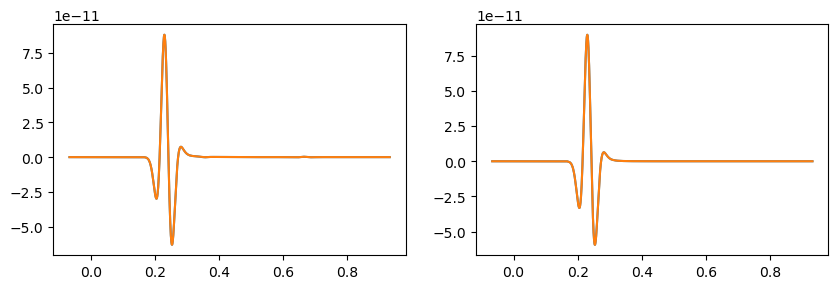

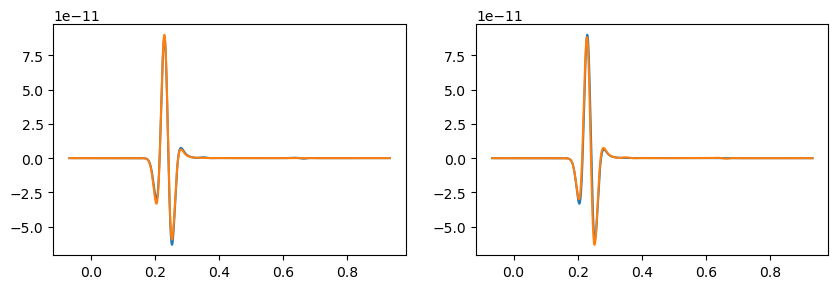

In [180]:
plt.figure(figsize=(10,3))

trs=read_su('res_AC/Ru_Shot0001.su',n=(2,nt)) #vz vx
plt.subplot(1,2,1); plt.plot(t,trs[:,0]); plt.grid()
plt.subplot(1,2,2); plt.plot(t,trs[:,1]); plt.grid()

trs=read_su('res_AC2nd/Ru_Shot0001.su',n=(2,nt)) #az ax
plt.subplot(1,2,1); plt.plot(t,np.cumsum(trs[:,0])*dt); plt.grid() #time integration on acceleration
plt.subplot(1,2,2); plt.plot(t,np.cumsum(trs[:,1])*dt); plt.grid()

plt.figure(figsize=(10,3))

trs=read_su('res_PSV/Ru_Shot0001.su',n=(2,nt)) #vz vx
plt.subplot(1,2,1); plt.plot(t,trs[:,0]); plt.grid()
plt.subplot(1,2,2); plt.plot(t,trs[:,1]); plt.grid()

trs=read_su('res_PSV2nd/Ru_Shot0001.su',n=(2,nt)) #uz ux
plt.subplot(1,2,1); plt.plot(t,np.gradient(trs[:,0])/dt); plt.grid() #time derivative on displacement
plt.subplot(1,2,2); plt.plot(t,np.gradient(trs[:,1])/dt); plt.grid()

Good match!

### w/ FS

In [181]:
# AC modeling
!cp setup_default2 setup
!echo "FS          '100   100 0'" >>setup
!echo "FR          '600   600 0'" >>setup

!echo "SCOMP            vz" >> setup
!echo "RCOMP           'vz vx'" >> setup
!echo "DIR_OUT       res_AC" >> setup
run(app='../../exe/fwd_AC_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           8
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/01_ForwardModeling_FreeSurface
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 wzhou wzhou 747248 Nov  9 15:56 ../../exe/fwd_AC_FDSG_O4_
 Git Commit: 2496904
 Git Branch: VisAC_ZFL_WZ
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 11/09/2025
System time: 16:29:40
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : res_AC
 Output directory:res_AC/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D/3D ACoustic propagation
1st-order Velocity-Stress(Pressure) formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   ->

In [182]:
# AC2nd modeling
!cp setup_default2 setup
!echo "FS          '100   100 0'" >>setup
!echo "FR          '600   600 0'" >>setup

!echo "SCOMP            az" >> setup
!echo "RCOMP           'az ax'" >> setup
!echo "DIR_OUT       res_AC2nd" >> setup
run(app='../../exe/fwd_AC2nd_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           8
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/01_ForwardModeling_FreeSurface
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 wzhou wzhou 738592 Nov  9 16:15 ../../exe/fwd_AC2nd_FDSG_O4_
 Git Commit: 2496904
 Git Branch: VisAC_ZFL_WZ
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 11/09/2025
System time: 16:29:42
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : res_AC2nd
 Output directory:res_AC2nd/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D/3D ACoustic propagation
2nd-order Pressure formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   -> dt ≤ 0.

In [183]:
# PSV modeling
!cp setup_default2 setup
!echo "FS          '100   100 0'" >>setup
!echo "FR          '600   600 0'" >>setup

!echo "SCOMP            vz" >> setup
!echo "RCOMP           'vz vx'" >> setup
!echo "DIR_OUT       res_PSV" >> setup
run(app='../../exe/fwd_PSV_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           8
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/01_ForwardModeling_FreeSurface
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 wzhou wzhou 751736 Nov  9 15:02 ../../exe/fwd_PSV_FDSG_O4_
 Git Commit: 2496904
 Git Branch: VisAC_ZFL_WZ
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 11/09/2025
System time: 16:29:44
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : res_PSV
 Output directory:res_PSV/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D P-SV (ELastic) propagation
1st-order Velocity-Stress formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   -> dt 

In [187]:
# PSV2nd modeling
!cp setup_default2 setup
!echo "FS          '100   100 0'" >>setup
!echo "FR          '600   600 0'" >>setup

!echo "SCOMP            uz" >> setup
!echo "RCOMP           'uz ux'" >> setup
!echo "DIR_OUT       res_PSV2nd" >> setup
run(app='../../exe/fwd_PSV2nd_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           8
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/01_ForwardModeling_FreeSurface
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 wzhou wzhou 759344 Nov  9 14:18 ../../exe/fwd_PSV2nd_FDSG_O4_
 Git Commit: 2496904
 Git Branch: VisAC_ZFL_WZ
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 11/09/2025
System time: 16:30:27
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : res_PSV2nd
 Output directory:res_PSV2nd/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D PSV (ELastic) propagation
2nd-order Displacement formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   -

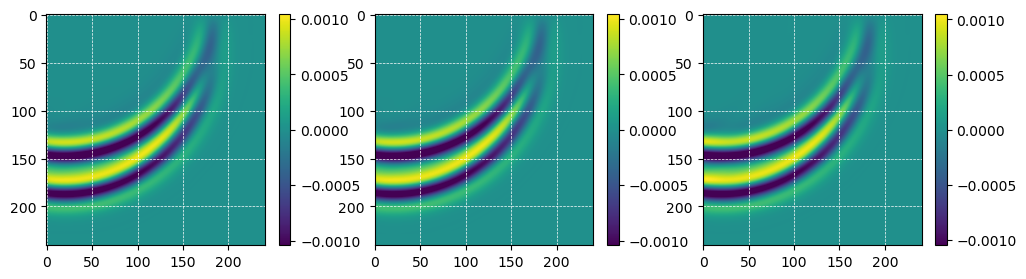

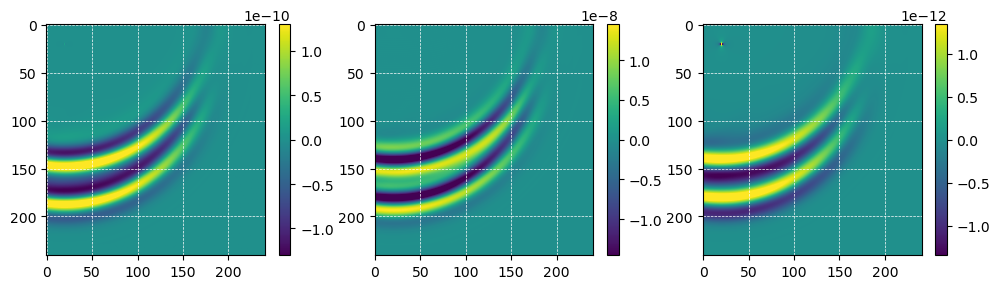

In [188]:
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read_snap('res_AC/snap_fld_reU%p'),perc=98) #pressure
plt.subplot(1,3,2); imshow(read_snap('res_AC2nd/snap_fld_reU%p'),perc=98) #pressure
plt.subplot(1,3,3); imshow((read_snap('res_PSV/snap_fld_reU%sz')+read_snap('res_PSV/snap_fld_reU%sx'))/2,perc=98) #pressure

plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read_snap('res_AC/snap_fld_reU%vz'),perc=98) #velocity
plt.subplot(1,3,2); imshow(read_snap('res_AC2nd/snap_fld_reU%az'),perc=98) #acceleration
plt.subplot(1,3,3); imshow(read_snap('res_PSV2nd/snap_fld_reU%uz'),perc=98) #displacement

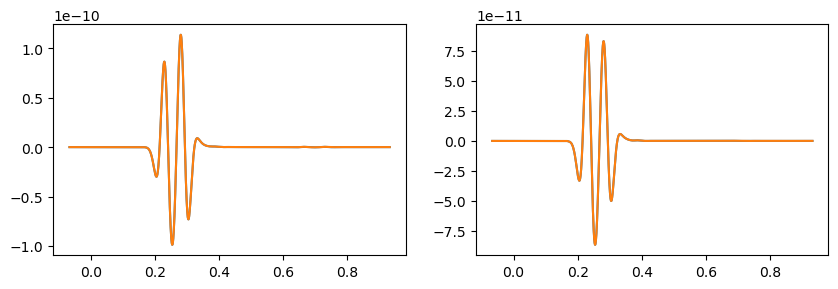

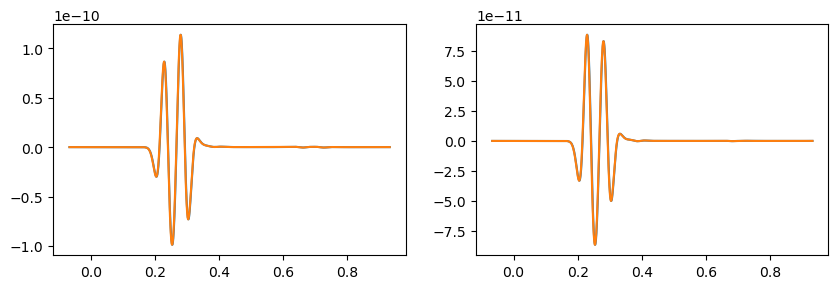

In [189]:
plt.figure(figsize=(10,3))

trs=read_su('res_AC/Ru_Shot0001.su',n=(2,nt)) #vz vx
plt.subplot(1,2,1); plt.plot(t,trs[:,0]); plt.grid()
plt.subplot(1,2,2); plt.plot(t,trs[:,1]); plt.grid()

trs=read_su('res_AC2nd/Ru_Shot0001.su',n=(2,nt)) #az ax
plt.subplot(1,2,1); plt.plot(t,np.cumsum(trs[:,0])*dt); plt.grid() #time integration on acceleration
plt.subplot(1,2,2); plt.plot(t,np.cumsum(trs[:,1])*dt); plt.grid()

plt.figure(figsize=(10,3))

trs=read_su('res_PSV/Ru_Shot0001.su',n=(2,nt)) #vz vx
plt.subplot(1,2,1); plt.plot(t,trs[:,0]); plt.grid()
plt.subplot(1,2,2); plt.plot(t,trs[:,1]); plt.grid()

trs=read_su('res_PSV2nd/Ru_Shot0001.su',n=(2,nt)) #uz ux
plt.subplot(1,2,1); plt.plot(t,np.gradient(trs[:,0])/dt); plt.grid() #time derivative on displacement
plt.subplot(1,2,2); plt.plot(t,np.gradient(trs[:,1])/dt); plt.grid()

Good match!

## Test hforce
Robertsson, Fig 1,2

In [190]:
# AC modeling
!cp setup_default2 setup
!echo "FS          '100   100 0'" >>setup
!echo "FR          '600   600 0'" >>setup

!echo "SCOMP            vx" >> setup
!echo "RCOMP           'vz vx'" >> setup
!echo "DIR_OUT       res_AC" >> setup
run(app='../../exe/fwd_AC_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           8
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/01_ForwardModeling_FreeSurface
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 wzhou wzhou 747248 Nov  9 15:56 ../../exe/fwd_AC_FDSG_O4_
 Git Commit: 2496904
 Git Branch: VisAC_ZFL_WZ
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 11/09/2025
System time: 16:31:06
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : res_AC
 Output directory:res_AC/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D/3D ACoustic propagation
1st-order Velocity-Stress(Pressure) formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   ->

In [191]:
# AC2nd modeling
!cp setup_default2 setup
!echo "FS          '100   100 0'" >>setup
!echo "FR          '600   600 0'" >>setup

!echo "SCOMP            ax" >> setup
!echo "RCOMP           'az ax'" >> setup
!echo "DIR_OUT       res_AC2nd" >> setup
run(app='../../exe/fwd_AC2nd_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           8
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/01_ForwardModeling_FreeSurface
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 wzhou wzhou 738592 Nov  9 16:15 ../../exe/fwd_AC2nd_FDSG_O4_
 Git Commit: 2496904
 Git Branch: VisAC_ZFL_WZ
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 11/09/2025
System time: 16:31:08
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : res_AC2nd
 Output directory:res_AC2nd/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D/3D ACoustic propagation
2nd-order Pressure formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   -> dt ≤ 0.

In [192]:
# PSV modeling
!cp setup_default2 setup
!echo "FS          '100   100 0'" >>setup
!echo "FR          '600   600 0'" >>setup

!echo "SCOMP            vx" >> setup
!echo "RCOMP           'vz vx'" >> setup
!echo "DIR_OUT       res_PSV" >> setup
run(app='../../exe/fwd_PSV_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           8
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/01_ForwardModeling_FreeSurface
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 wzhou wzhou 751736 Nov  9 15:02 ../../exe/fwd_PSV_FDSG_O4_
 Git Commit: 2496904
 Git Branch: VisAC_ZFL_WZ
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 11/09/2025
System time: 16:31:11
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : res_PSV
 Output directory:res_PSV/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D P-SV (ELastic) propagation
1st-order Velocity-Stress formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   -> dt 

In [193]:
# PSV2nd modeling
!cp setup_default2 setup
!echo "FS          '100   100 0'" >>setup
!echo "FR          '600   600 0'" >>setup

!echo "SCOMP            ux" >> setup
!echo "RCOMP           'uz ux'" >> setup
!echo "DIR_OUT       res_PSV2nd" >> setup
run(app='../../exe/fwd_PSV2nd_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           8
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/01_ForwardModeling_FreeSurface
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 wzhou wzhou 759344 Nov  9 14:18 ../../exe/fwd_PSV2nd_FDSG_O4_
 Git Commit: 2496904
 Git Branch: VisAC_ZFL_WZ
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 11/09/2025
System time: 16:31:13
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : res_PSV2nd
 Output directory:res_PSV2nd/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D PSV (ELastic) propagation
2nd-order Displacement formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   -

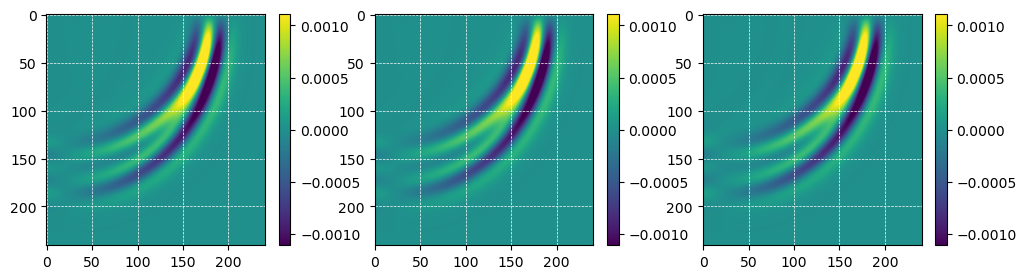

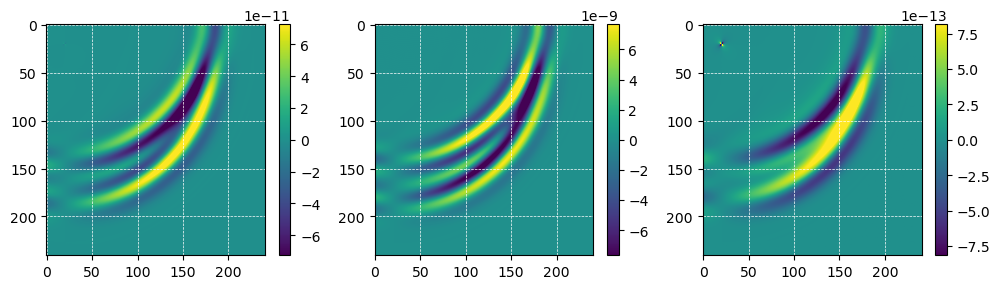

In [194]:
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read_snap('res_AC/snap_fld_reU%p'),perc=98) #pressure
plt.subplot(1,3,2); imshow(read_snap('res_AC2nd/snap_fld_reU%p'),perc=98) #pressure
plt.subplot(1,3,3); imshow((read_snap('res_PSV/snap_fld_reU%sz')+read_snap('res_PSV/snap_fld_reU%sx'))/2,perc=98) #pressure

plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read_snap('res_AC/snap_fld_reU%vz'),perc=98) #velocity
plt.subplot(1,3,2); imshow(read_snap('res_AC2nd/snap_fld_reU%az'),perc=98) #acceleration
plt.subplot(1,3,3); imshow(read_snap('res_PSV2nd/snap_fld_reU%uz'),perc=98) #displacement

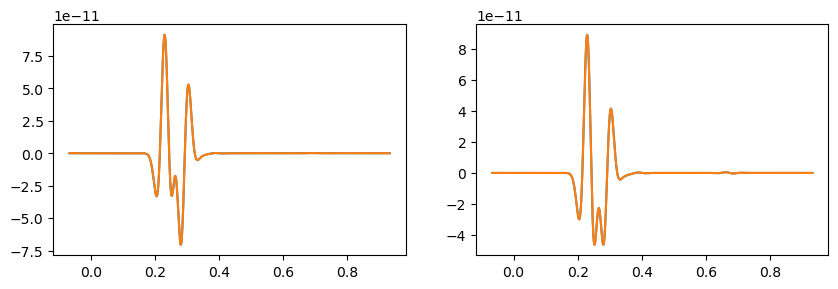

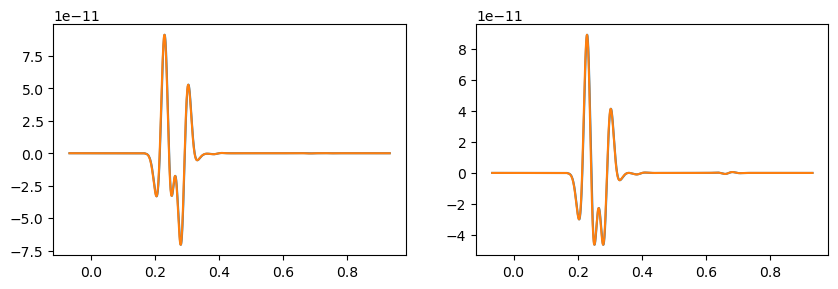

In [195]:
plt.figure(figsize=(10,3))

trs=read_su('res_AC/Ru_Shot0001.su',n=(2,nt)) #vz vx
plt.subplot(1,2,1); plt.plot(t,trs[:,0]); plt.grid()
plt.subplot(1,2,2); plt.plot(t,trs[:,1]); plt.grid()

trs=read_su('res_AC2nd/Ru_Shot0001.su',n=(2,nt)) #az ax
plt.subplot(1,2,1); plt.plot(t,np.cumsum(trs[:,0])*dt); plt.grid() #time integration on acceleration
plt.subplot(1,2,2); plt.plot(t,np.cumsum(trs[:,1])*dt); plt.grid()

plt.figure(figsize=(10,3))

trs=read_su('res_PSV/Ru_Shot0001.su',n=(2,nt)) #vz vx
plt.subplot(1,2,1); plt.plot(t,trs[:,0]); plt.grid()
plt.subplot(1,2,2); plt.plot(t,trs[:,1]); plt.grid()

trs=read_su('res_PSV2nd/Ru_Shot0001.su',n=(2,nt)) #uz ux
plt.subplot(1,2,1); plt.plot(t,np.gradient(trs[:,0])/dt); plt.grid() #time derivative on displacement
plt.subplot(1,2,2); plt.plot(t,np.gradient(trs[:,1])/dt); plt.grid()

Good match!

## acqui close to FS
Robertsson, Fig 1,2

### Test vforce

In [196]:
# AC modeling
!cp setup_default2 setup
!echo "FS          '10   100 0'" >>setup
!echo "FR          '10   600 0'" >>setup

!echo "SCOMP            vz" >> setup
!echo "RCOMP           'vz vx'" >> setup
!echo "DIR_OUT       res_AC" >> setup
run(app='../../exe/fwd_AC_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           8
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/01_ForwardModeling_FreeSurface
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 wzhou wzhou 747248 Nov  9 15:56 ../../exe/fwd_AC_FDSG_O4_
 Git Commit: 2496904
 Git Branch: VisAC_ZFL_WZ
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 11/09/2025
System time: 16:31:59
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : res_AC
 Output directory:res_AC/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D/3D ACoustic propagation
1st-order Velocity-Stress(Pressure) formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   ->

In [197]:
# AC2nd modeling
!cp setup_default2 setup
!echo "FS          '10   100 0'" >>setup
!echo "FR          '10   600 0'" >>setup

!echo "SCOMP            az" >> setup
!echo "RCOMP           'az ax'" >> setup
!echo "DIR_OUT       res_AC2nd" >> setup
run(app='../../exe/fwd_AC2nd_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           8
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/01_ForwardModeling_FreeSurface
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 wzhou wzhou 738592 Nov  9 16:15 ../../exe/fwd_AC2nd_FDSG_O4_
 Git Commit: 2496904
 Git Branch: VisAC_ZFL_WZ
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 11/09/2025
System time: 16:32:01
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : res_AC2nd
 Output directory:res_AC2nd/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D/3D ACoustic propagation
2nd-order Pressure formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   -> dt ≤ 0.

In [198]:
# PSV modeling
!cp setup_default2 setup
!echo "FS          '10   100 0'" >>setup
!echo "FR          '10   600 0'" >>setup

!echo "SCOMP            vz" >> setup
!echo "RCOMP           'vz vx'" >> setup
!echo "DIR_OUT       res_PSV" >> setup
run(app='../../exe/fwd_PSV_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           8
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/01_ForwardModeling_FreeSurface
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 wzhou wzhou 751736 Nov  9 15:02 ../../exe/fwd_PSV_FDSG_O4_
 Git Commit: 2496904
 Git Branch: VisAC_ZFL_WZ
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 11/09/2025
System time: 16:32:03
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : res_PSV
 Output directory:res_PSV/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D P-SV (ELastic) propagation
1st-order Velocity-Stress formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   -> dt 

In [199]:
# PSV2nd modeling
!cp setup_default2 setup
!echo "FS          '10   100 0'" >>setup
!echo "FR          '10   600 0'" >>setup

!echo "SCOMP            uz" >> setup
!echo "RCOMP           'uz ux'" >> setup
!echo "DIR_OUT       res_PSV2nd" >> setup
run(app='../../exe/fwd_PSV2nd_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           8
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/01_ForwardModeling_FreeSurface
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 wzhou wzhou 759344 Nov  9 14:18 ../../exe/fwd_PSV2nd_FDSG_O4_
 Git Commit: 2496904
 Git Branch: VisAC_ZFL_WZ
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 11/09/2025
System time: 16:32:06
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : res_PSV2nd
 Output directory:res_PSV2nd/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D PSV (ELastic) propagation
2nd-order Displacement formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   -

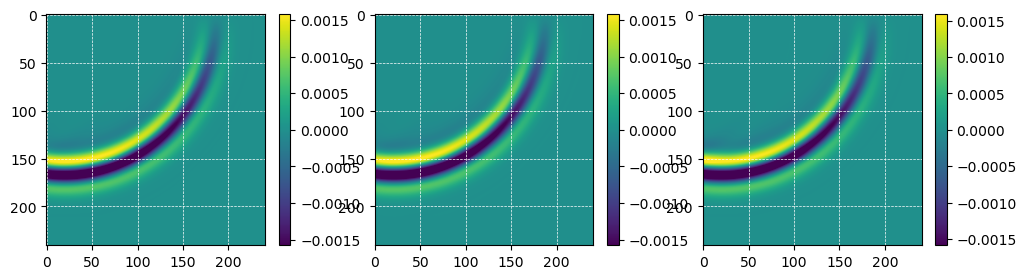

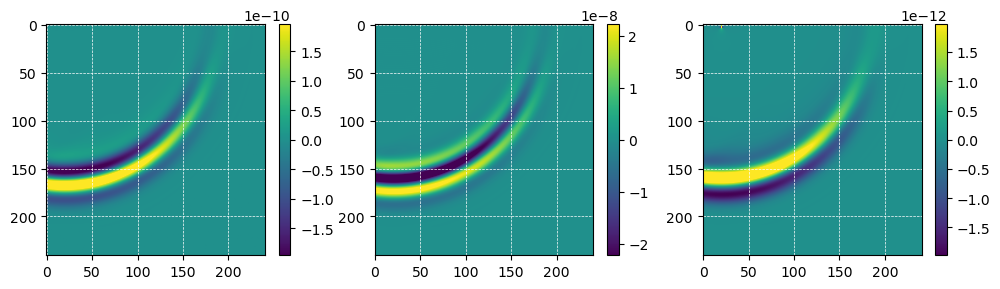

In [200]:
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read_snap('res_AC/snap_fld_reU%p'),perc=98) #pressure
plt.subplot(1,3,2); imshow(read_snap('res_AC2nd/snap_fld_reU%p'),perc=98) #pressure
plt.subplot(1,3,3); imshow((read_snap('res_PSV/snap_fld_reU%sz')+read_snap('res_PSV/snap_fld_reU%sx'))/2,perc=98) #pressure

plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read_snap('res_AC/snap_fld_reU%vz'),perc=98) #velocity
plt.subplot(1,3,2); imshow(read_snap('res_AC2nd/snap_fld_reU%az'),perc=98) #acceleration
plt.subplot(1,3,3); imshow(read_snap('res_PSV2nd/snap_fld_reU%uz'),perc=98) #displacement

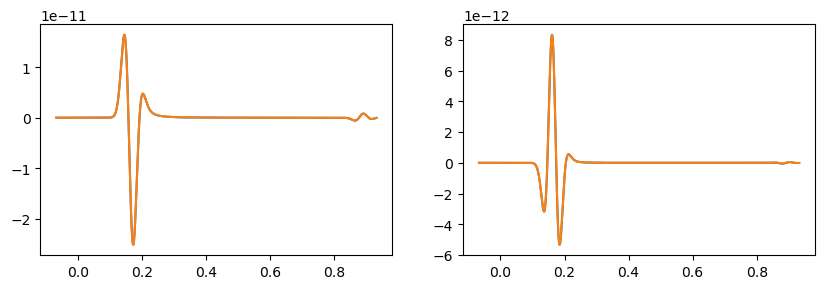

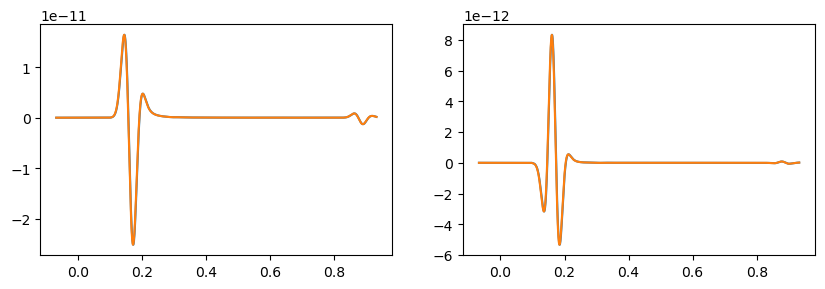

In [201]:
plt.figure(figsize=(10,3))

trs=read_su('res_AC/Ru_Shot0001.su',n=(2,nt)) #vz vx
plt.subplot(1,2,1); plt.plot(t,trs[:,0]); plt.grid()
plt.subplot(1,2,2); plt.plot(t,trs[:,1]); plt.grid()

trs=read_su('res_AC2nd/Ru_Shot0001.su',n=(2,nt)) #az ax
plt.subplot(1,2,1); plt.plot(t,np.cumsum(trs[:,0])*dt); plt.grid() #time integration on acceleration
plt.subplot(1,2,2); plt.plot(t,np.cumsum(trs[:,1])*dt); plt.grid()

plt.figure(figsize=(10,3))

trs=read_su('res_PSV/Ru_Shot0001.su',n=(2,nt)) #vz vx
plt.subplot(1,2,1); plt.plot(t,trs[:,0]); plt.grid()
plt.subplot(1,2,2); plt.plot(t,trs[:,1]); plt.grid()

trs=read_su('res_PSV2nd/Ru_Shot0001.su',n=(2,nt)) #uz ux
plt.subplot(1,2,1); plt.plot(t,np.gradient(trs[:,0])/dt); plt.grid() #time derivative on displacement
plt.subplot(1,2,2); plt.plot(t,np.gradient(trs[:,1])/dt); plt.grid()

Good match!

### Test hforce

In [202]:
# AC modeling
!cp setup_default2 setup
!echo "FS          '100   100 0'" >>setup
!echo "FR          '600   600 0'" >>setup

!echo "SCOMP            vx" >> setup
!echo "RCOMP           'vz vx'" >> setup
!echo "DIR_OUT       res_AC" >> setup
run(app='../../exe/fwd_AC_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           8
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/01_ForwardModeling_FreeSurface
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 wzhou wzhou 747248 Nov  9 15:56 ../../exe/fwd_AC_FDSG_O4_
 Git Commit: 2496904
 Git Branch: VisAC_ZFL_WZ
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 11/09/2025
System time: 16:32:43
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : res_AC
 Output directory:res_AC/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D/3D ACoustic propagation
1st-order Velocity-Stress(Pressure) formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   ->

In [203]:
# AC2nd modeling
!cp setup_default2 setup
!echo "FS          '100   100 0'" >>setup
!echo "FR          '600   600 0'" >>setup

!echo "SCOMP            ax" >> setup
!echo "RCOMP           'az ax'" >> setup
!echo "DIR_OUT       res_AC2nd" >> setup
run(app='../../exe/fwd_AC2nd_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           8
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/01_ForwardModeling_FreeSurface
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 wzhou wzhou 738592 Nov  9 16:15 ../../exe/fwd_AC2nd_FDSG_O4_
 Git Commit: 2496904
 Git Branch: VisAC_ZFL_WZ
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 11/09/2025
System time: 16:32:45
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : res_AC2nd
 Output directory:res_AC2nd/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D/3D ACoustic propagation
2nd-order Pressure formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   -> dt ≤ 0.

In [204]:
# PSV modeling
!cp setup_default2 setup
!echo "FS          '100   100 0'" >>setup
!echo "FR          '600   600 0'" >>setup

!echo "SCOMP            vx" >> setup
!echo "RCOMP           'vz vx'" >> setup
!echo "DIR_OUT       res_PSV" >> setup
run(app='../../exe/fwd_PSV_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           8
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/01_ForwardModeling_FreeSurface
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 wzhou wzhou 751736 Nov  9 15:02 ../../exe/fwd_PSV_FDSG_O4_
 Git Commit: 2496904
 Git Branch: VisAC_ZFL_WZ
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 11/09/2025
System time: 16:32:47
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : res_PSV
 Output directory:res_PSV/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D P-SV (ELastic) propagation
1st-order Velocity-Stress formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   -> dt 

In [205]:
# PSV2nd modeling
!cp setup_default2 setup
!echo "FS          '100   100 0'" >>setup
!echo "FR          '600   600 0'" >>setup

!echo "SCOMP            ux" >> setup
!echo "RCOMP           'uz ux'" >> setup
!echo "DIR_OUT       res_PSV2nd" >> setup
run(app='../../exe/fwd_PSV2nd_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           8
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/01_ForwardModeling_FreeSurface
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 wzhou wzhou 759344 Nov  9 14:18 ../../exe/fwd_PSV2nd_FDSG_O4_
 Git Commit: 2496904
 Git Branch: VisAC_ZFL_WZ
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 11/09/2025
System time: 16:32:50
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : res_PSV2nd
 Output directory:res_PSV2nd/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D PSV (ELastic) propagation
2nd-order Displacement formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   -

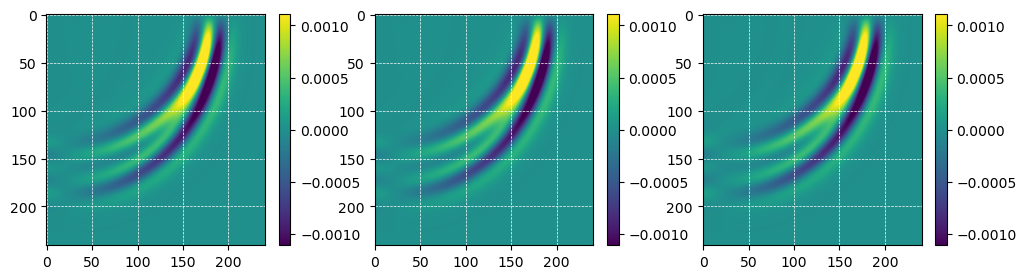

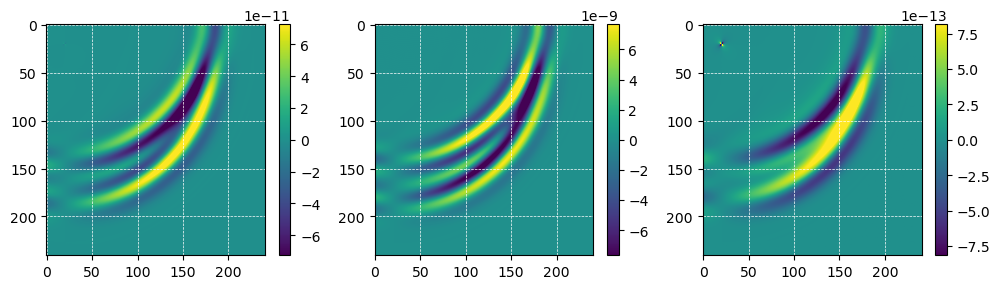

In [206]:
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read_snap('res_AC/snap_fld_reU%p'),perc=98) #pressure
plt.subplot(1,3,2); imshow(read_snap('res_AC2nd/snap_fld_reU%p'),perc=98) #pressure
plt.subplot(1,3,3); imshow((read_snap('res_PSV/snap_fld_reU%sz')+read_snap('res_PSV/snap_fld_reU%sx'))/2,perc=98) #pressure

plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read_snap('res_AC/snap_fld_reU%vz'),perc=98) #velocity
plt.subplot(1,3,2); imshow(read_snap('res_AC2nd/snap_fld_reU%az'),perc=98) #acceleration
plt.subplot(1,3,3); imshow(read_snap('res_PSV2nd/snap_fld_reU%uz'),perc=98) #displacement

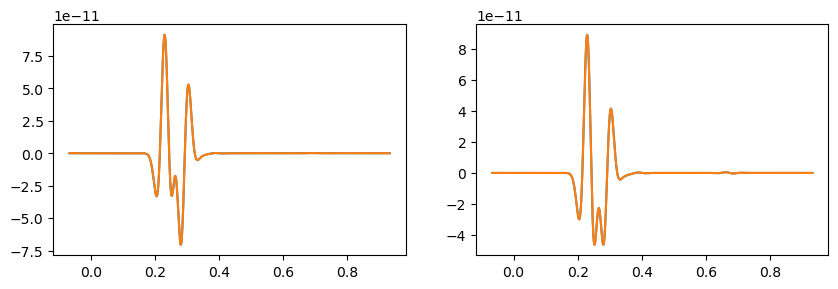

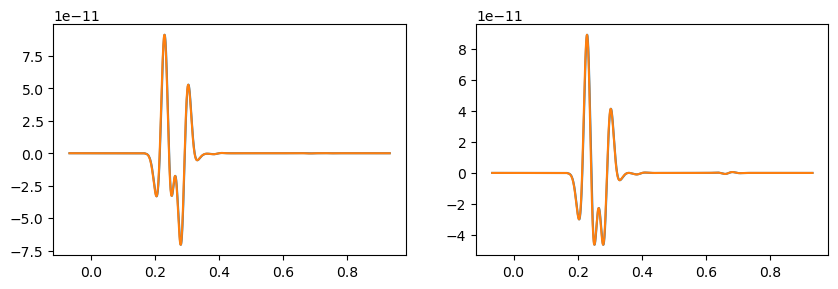

In [207]:
plt.figure(figsize=(10,3))

trs=read_su('res_AC/Ru_Shot0001.su',n=(2,nt)) #vz vx
plt.subplot(1,2,1); plt.plot(t,trs[:,0]); plt.grid()
plt.subplot(1,2,2); plt.plot(t,trs[:,1]); plt.grid()

trs=read_su('res_AC2nd/Ru_Shot0001.su',n=(2,nt)) #az ax
plt.subplot(1,2,1); plt.plot(t,np.cumsum(trs[:,0])*dt); plt.grid() #time integration on acceleration
plt.subplot(1,2,2); plt.plot(t,np.cumsum(trs[:,1])*dt); plt.grid()

plt.figure(figsize=(10,3))

trs=read_su('res_PSV/Ru_Shot0001.su',n=(2,nt)) #vz vx
plt.subplot(1,2,1); plt.plot(t,trs[:,0]); plt.grid()
plt.subplot(1,2,2); plt.plot(t,trs[:,1]); plt.grid()

trs=read_su('res_PSV2nd/Ru_Shot0001.su',n=(2,nt)) #uz ux
plt.subplot(1,2,1); plt.plot(t,np.gradient(trs[:,0])/dt); plt.grid() #time derivative on displacement
plt.subplot(1,2,2); plt.plot(t,np.gradient(trs[:,1])/dt); plt.grid()

Good match!

## Test ELastic

In [3]:
!makevel nx=$nx nz=$nz v000=$vp  > vp
!makevel nx=$nx nz=$nz v000=1730 > vs  #=vp/sqrt(3)
!makevel nx=$nx nz=$nz v000=$rho> rho
!cat vp vs rho > model

### vforce

In [151]:
!cp setup_default2 setup
!echo "FS          '100   100 0'" >>setup
!echo "FR          '600   600 0'" >>setup

!echo "SCOMP         vz" >> setup
!echo "RCOMP        'vz vx'" >> setup
!echo "DIR_OUT       res_PSV" >> setup
run(app='../../exe/fwd_PSV_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           8
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/01_ForwardModeling_FreeSurface
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 wzhou wzhou 751736 Nov  9 15:02 ../../exe/fwd_PSV_FDSG_O4_
 Git Commit: 2496904
 Git Branch: VisAC_ZFL_WZ
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 11/09/2025
System time: 15:03:22
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : res_PSV
 Output directory:res_PSV/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D P-SV (ELastic) propagation
1st-order Velocity-Stress formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   -> dt 

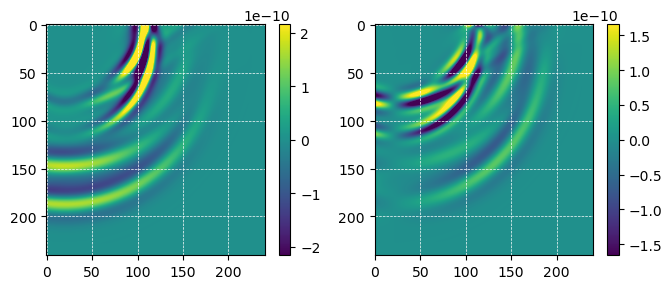

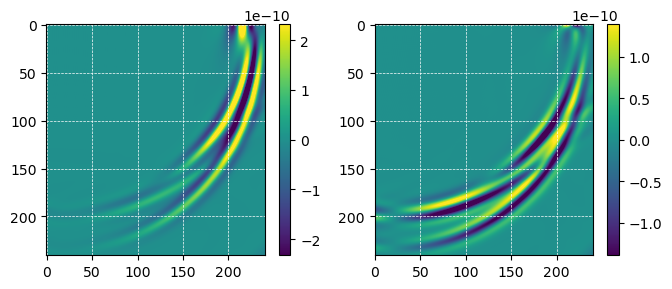

In [153]:
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read_snap('res_PSV/snap_fld_reU%vz'),perc=98)
plt.subplot(1,3,2); imshow(read_snap('res_PSV/snap_fld_reU%vx'),perc=98)

plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read_snap('res_PSV/snap_fld_reU%vz',i=34),perc=98)
plt.subplot(1,3,2); imshow(read_snap('res_PSV/snap_fld_reU%vx',i=34),perc=98)

In [154]:
!cp setup_default2 setup
!echo "FS          '100   100 0'" >>setup
!echo "FR          '600   600 0'" >>setup

!echo "SCOMP         uz" >> setup
!echo "RCOMP        'uz ux'" >> setup
!echo "DIR_OUT       res_PSV2nd" >> setup
run(app='../../exe/fwd_PSV2nd_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           8
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/01_ForwardModeling_FreeSurface
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 wzhou wzhou 759344 Nov  9 14:18 ../../exe/fwd_PSV2nd_FDSG_O4_
 Git Commit: 2496904
 Git Branch: VisAC_ZFL_WZ
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 11/09/2025
System time: 15:03:41
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : res_PSV2nd
 Output directory:res_PSV2nd/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D PSV (ELastic) propagation
2nd-order Displacement formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   -

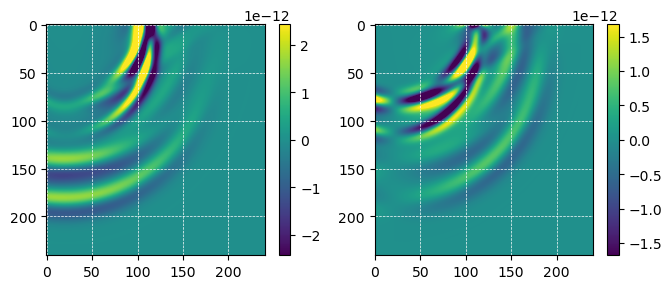

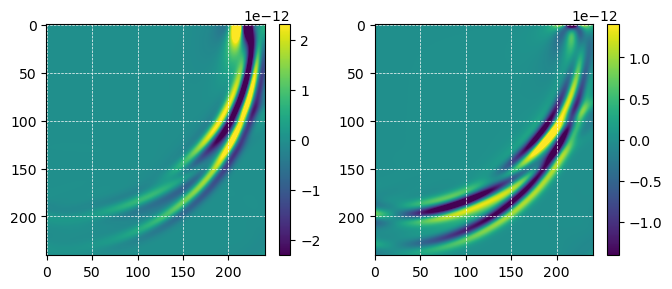

In [155]:
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read_snap('res_PSV2nd/snap_fld_reU%uz'),perc=98)
plt.subplot(1,3,2); imshow(read_snap('res_PSV2nd/snap_fld_reU%ux'),perc=98)

plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read_snap('res_PSV2nd/snap_fld_reU%uz',i=34),perc=98)
plt.subplot(1,3,2); imshow(read_snap('res_PSV2nd/snap_fld_reU%ux',i=34),perc=98)

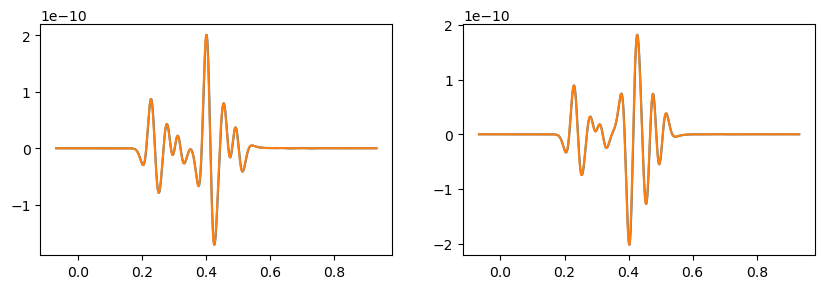

In [156]:
trs1=read_su('res_PSV/Ru_Shot0001.su',n=(2,nt)) #velocity
trs2=read_su('res_PSV2nd/Ru_Shot0001.su',n=(2,nt)) #displacement

plt.figure(figsize=(10,3))
plt.subplot(1,2,1); plt.plot(t,trs1[:,0]); plt.grid()
plt.subplot(1,2,2); plt.plot(t,trs1[:,1]); plt.grid()

plt.subplot(1,2,1); plt.plot(t,np.gradient(trs2[:,0])/dt); plt.grid() #time derivative on displacement
plt.subplot(1,2,2); plt.plot(t,np.gradient(trs2[:,1])/dt); plt.grid()

Good match!

### mtensor

In [146]:
!cp setup_default2 setup
!echo "FS          '100   100 0'" >>setup
!echo "FR          '600   600 0'" >>setup

!echo "SCOMP         sx" >> setup
!echo "RCOMP        'vz vx'" >> setup
!echo "IF_SNAPSHOT      'T'" >> setup
!echo "DIR_OUT       res_PSV" >> setup
run(app='../../exe/fwd_PSV_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           8
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/01_ForwardModeling_FreeSurface
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 wzhou wzhou 751736 Nov  9 14:18 ../../exe/fwd_PSV_FDSG_O4_
 Git Commit: 2496904
 Git Branch: VisAC_ZFL_WZ
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 11/09/2025
System time: 15:00:06
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : res_PSV
 Output directory:res_PSV/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D P-SV (ELastic) propagation
1st-order Velocity-Stress formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   -> dt 

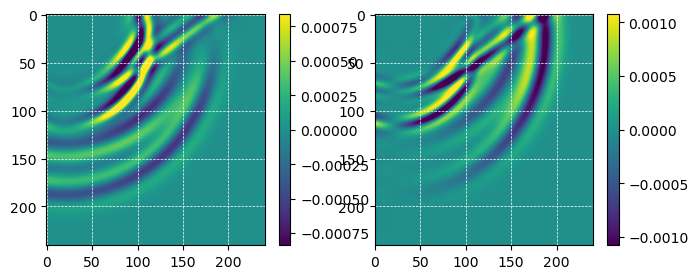

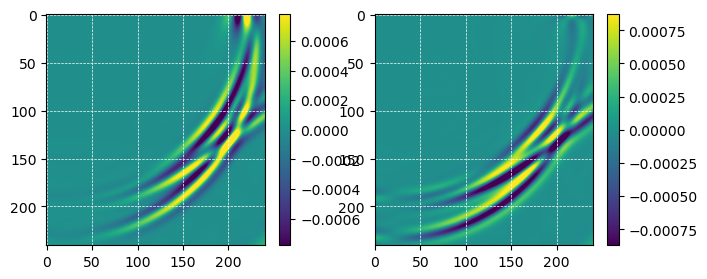

In [147]:
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read_snap('res_PSV/snap_fld_reU%vz'),perc=98)
plt.subplot(1,3,2); imshow(read_snap('res_PSV/snap_fld_reU%vx'),perc=98)

plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read_snap('res_PSV/snap_fld_reU%vz',i=34),perc=98)
plt.subplot(1,3,2); imshow(read_snap('res_PSV/snap_fld_reU%vx',i=34),perc=98)

In [148]:
!cp setup_default2 setup
!echo "FS          '100   100 0'" >>setup
!echo "FR          '600   600 0'" >>setup

!echo "SCOMP         sx" >> setup
!echo "RCOMP        'uz ux'" >> setup
!echo "IF_SNAPSHOT      'T'" >> setup
!echo "DIR_OUT       res_PSV2nd" >> setup
run(app='../../exe/fwd_PSV2nd_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           8
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/01_ForwardModeling_FreeSurface
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 wzhou wzhou 759344 Nov  9 14:18 ../../exe/fwd_PSV2nd_FDSG_O4_
 Git Commit: 2496904
 Git Branch: VisAC_ZFL_WZ
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 11/09/2025
System time: 15:00:11
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : res_PSV2nd
 Output directory:res_PSV2nd/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D PSV (ELastic) propagation
2nd-order Displacement formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   -

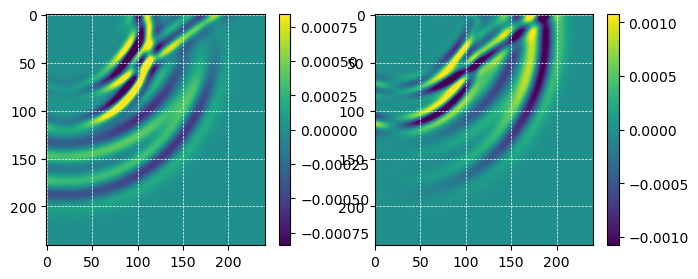

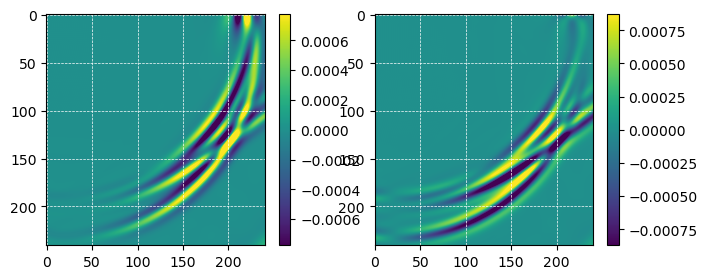

In [149]:
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read_snap('res_PSV2nd/snap_fld_reU%uz'),perc=98)
plt.subplot(1,3,2); imshow(read_snap('res_PSV2nd/snap_fld_reU%ux'),perc=98)

plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read_snap('res_PSV2nd/snap_fld_reU%uz',i=34),perc=98)
plt.subplot(1,3,2); imshow(read_snap('res_PSV2nd/snap_fld_reU%ux',i=34),perc=98)

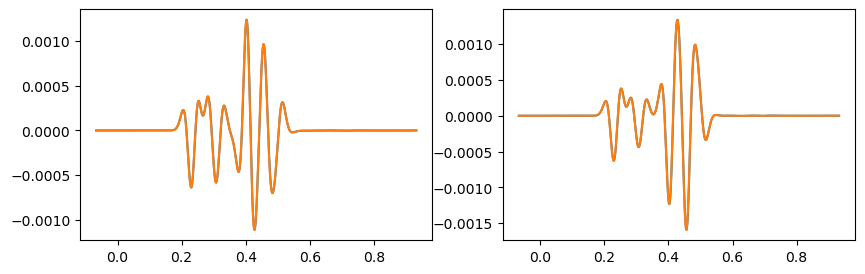

In [150]:
trs1=read_su('res_PSV/Ru_Shot0001.su',n=(2,nt)) #velocity
trs2=read_su('res_PSV2nd/Ru_Shot0001.su',n=(2,nt)) #time derivative on displacement

plt.figure(figsize=(10,3))
plt.subplot(1,2,1); plt.plot(t,trs1[:,0]); plt.grid()
plt.subplot(1,2,2); plt.plot(t,trs1[:,1]); plt.grid()

plt.subplot(1,2,1); plt.plot(t,trs2[:,0]); plt.grid()
plt.subplot(1,2,2); plt.plot(t,trs2[:,1]); plt.grid()

Good match!

## Test ViscoAcoustic

In [213]:
!makevel nx=$nx nz=$nz v000=$vp  > vp
!makevel nx=$nx nz=$nz v000=$rho > rho
!makevel nx=$nx nz=$nz v000=100  > qp
!cat vp rho qp > model

In [214]:
# AC2nd modeling
!cp setup_default2 setup

!echo "MODEL_ATTRIBUTES   'vp rho qp'" >> setup
!echo "FS          '100   100 0'" >>setup
!echo "FR          '600   600 0'" >>setup

!echo "SCOMP            az" >> setup
!echo "RCOMP           'az ax'" >> setup
!echo "DIR_OUT       res_AC2nd" >> setup
run(app='../../exe/fwd_AC2nd_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           8
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/01_ForwardModeling_FreeSurface
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 wzhou wzhou 738592 Nov  9 17:19 ../../exe/fwd_AC2nd_FDSG_O4_
 Git Commit: b2b4d0f
 Git Branch: VisAC_ZFL_WZ
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 11/09/2025
System time: 17:23:08
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : res_AC2nd
 Output directory:res_AC2nd/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D/3D ACoustic propagation
2nd-order Pressure formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   -> dt ≤ 0.

In [224]:
# VisAC2nd modeling
!cp setup_default2 setup

!echo "MODEL_ATTRIBUTES   'vp rho qp'" >> setup
!echo "FS          '100   100 0'" >>setup
!echo "FR          '600   600 0'" >>setup

!echo "SCOMP            az" >> setup
!echo "RCOMP           'az ax'" >> setup
!echo "DIR_OUT       res_VisAC2nd" >> setup
run(app='../../exe/fwd_VisAC2nd_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           8
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/01_ForwardModeling_FreeSurface
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 wzhou wzhou 801368 Nov  9 17:42 ../../exe/fwd_VisAC2nd_FDSG_O4_
 Git Commit: b2b4d0f
 Git Branch: VisAC_ZFL_WZ
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 11/09/2025
System time: 17:42:13
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : res_VisAC2nd
 Output directory:res_VisAC2nd/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D/3D VIScoACoustic propagation
2nd-order Pressure formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal

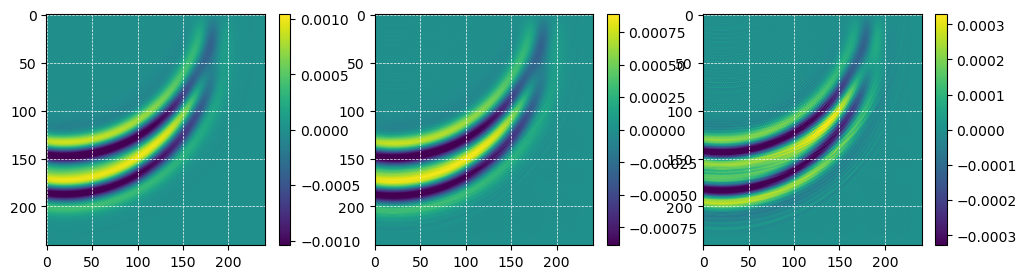

In [225]:
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read_snap('res_AC2nd/snap_fld_reU%p'),perc=98) #pressure
plt.subplot(1,3,2); imshow(read_snap('res_VisAC2nd/snap_fld_reU%p'),perc=98) #pressure
plt.subplot(1,3,3); imshow(read_snap('res_AC2nd/snap_fld_reU%p')-read_snap('res_VisAC2nd/snap_fld_reU%p'),perc=98)

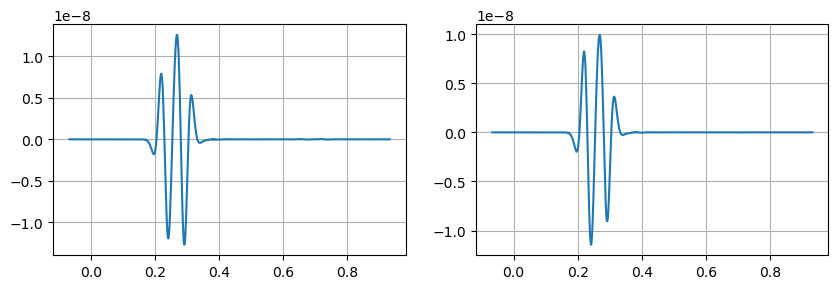

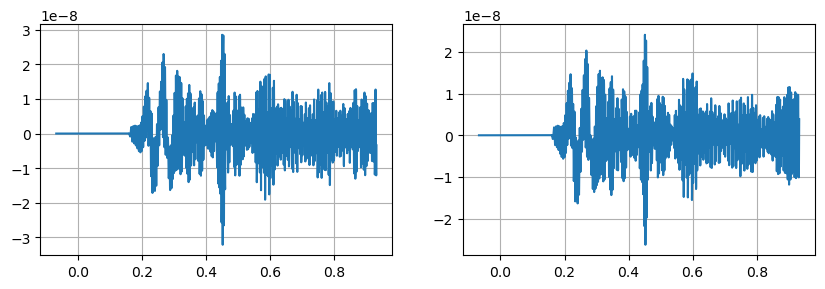

In [226]:
plt.figure(figsize=(10,3))
trs=read_su('res_AC2nd/Ru_Shot0001.su',n=(2,nt)) #az ax
plt.subplot(1,2,1); plt.plot(t,trs[:,0]); plt.grid()
plt.subplot(1,2,2); plt.plot(t,trs[:,1]); plt.grid()

plt.figure(figsize=(10,3))
trs=read_su('res_VisAC2nd/Ru_Shot0001.su',n=(2,nt)) #az ax
plt.subplot(1,2,1); plt.plot(t,trs[:,0]); plt.grid()
plt.subplot(1,2,2); plt.plot(t,trs[:,1]); plt.grid()


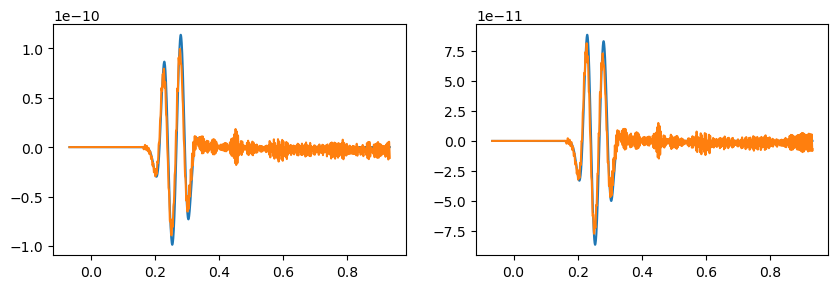

In [228]:
plt.figure(figsize=(10,3))

trs=read_su('res_AC2nd/Ru_Shot0001.su',n=(2,nt)) #az ax
plt.subplot(1,2,1); plt.plot(t,np.cumsum(trs[:,0])*dt); plt.grid() #time integration on acceleration
plt.subplot(1,2,2); plt.plot(t,np.cumsum(trs[:,1])*dt); plt.grid()

trs=read_su('res_VisAC2nd/Ru_Shot0001.su',n=(2,nt)) #az ax
plt.subplot(1,2,1); plt.plot(t,np.cumsum(trs[:,0])*dt); plt.grid() #time integration on acceleration
plt.subplot(1,2,2); plt.plot(t,np.cumsum(trs[:,1])*dt); plt.grid()


Good match, regardless of the instability..